Final Combined Model (No Constant Term) Coefficients:
a (Log Age Coefficient): 7.2086
c (Exponential UPV Coefficient): 0.4238
d (Rate for Exponential UPV): 0.7560
f (Log ER Coefficient): -0.4272
R² Value: 0.7700


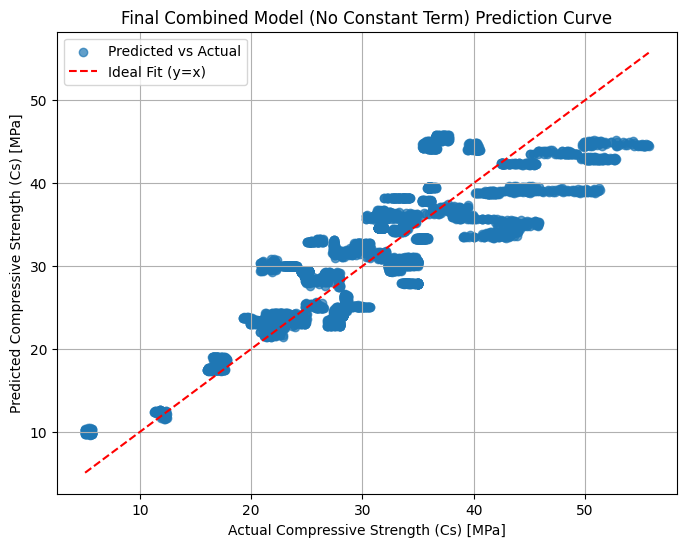

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load your dataset
# Replace 'your_dataset.csv' with the actual file path or upload method
data = pd.read_csv('/content/Untitled spreadsheet - Data.csv')

# Remove the 'Design_F\'c (Mpa)' column
if 'Design_F\'c (Mpa)' in data.columns:
    data = data.drop('Design_F\'c (Mpa)', axis=1)

# Extract relevant columns (adjust column names to match your dataset)
age = data["Curing_age_(days)"].values
upv = data["UPV_(m/s)"].values
er = data["Er_(ohm-cm)"].values
cs = data["Cs_(Mpa)"].values

# Define the logarithmic age formula
def age_formula_log(x, A):
    return A * np.log(x)

def upv_formula(x, C, D):  # Define the UPV equation
    return C * np.exp(D * (x / 1000))

def er_formula(x, F):  # Define the ER equation
    return F * np.log(x)


# Define the final combined model without the constant term
# Define the combined model:
def combined_model(x, A, C, D, F):
    age, upv, er = x[0], x[1], x[2]
    age_component = age_formula_log(age, A)
    upv_component = upv_formula(upv, C, D)
    er_component = er_formula(er, F)
    return age_component + upv_component + er_component  # Combine the components

# Fit the final combined model without the constant term
params_final_combined_no_constant, _ = curve_fit(
    combined_model,
    (age, upv, er),
    cs,
    p0=[1, 1, 0.1, 1],  # Initial guesses for coefficients
    maxfev=5000
)

# Calculate predictions and R² for the model without the constant term
predicted_final_combined_no_constant = combined_model(
    (age, upv, er), *params_final_combined_no_constant)
r2_final_combined_no_constant = r2_score(cs, predicted_final_combined_no_constant)

# Display the coefficients and R² value
print("Final Combined Model (No Constant Term) Coefficients:")
print(f"a (Log Age Coefficient): {params_final_combined_no_constant[0]:.4f}")
print(f"c (Exponential UPV Coefficient): {params_final_combined_no_constant[1]:.4f}")
print(f"d (Rate for Exponential UPV): {params_final_combined_no_constant[2]:.4f}")
print(f"f (Log ER Coefficient): {params_final_combined_no_constant[3]:.4f}")
print(f"R² Value: {r2_final_combined_no_constant:.4f}")

# Plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(cs, predicted_final_combined_no_constant, alpha=0.7, label="Predicted vs Actual")
plt.plot([cs.min(), cs.max()], [cs.min(), cs.max()], 'r--', label="Ideal Fit (y=x)")
plt.xlabel("Actual Compressive Strength (Cs) [MPa]")
plt.ylabel("Predicted Compressive Strength (Cs) [MPa]")
plt.title("Final Combined Model (No Constant Term) Prediction Curve")
plt.legend()
plt.grid(True)
plt.show()